In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

print(mssfp.__version__)

0.0.5


In [2]:
mode = deepssfp.DataMode.SyntheticBanding.value
model_name = "block_phantom"
model_dir = "D:/DeepSSFP/"
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
ds_path = os.path.join(model_dir, f"{model_name}_dataset.npy")
print(path, ds_path)

D:/DeepSSFP/block_phantom_syntheticbanding D:/DeepSSFP/block_phantom_dataset.npy


Saved dataset found. Loading from file: D:/DeepSSFP/block_phantom_dataset.npy


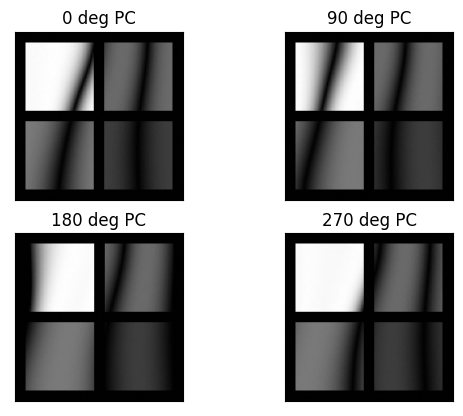

(160, 128, 128, 4) (160, 128, 128, 4)
Selected indices: [ 7 11 28]
Figure size: (8, 6)


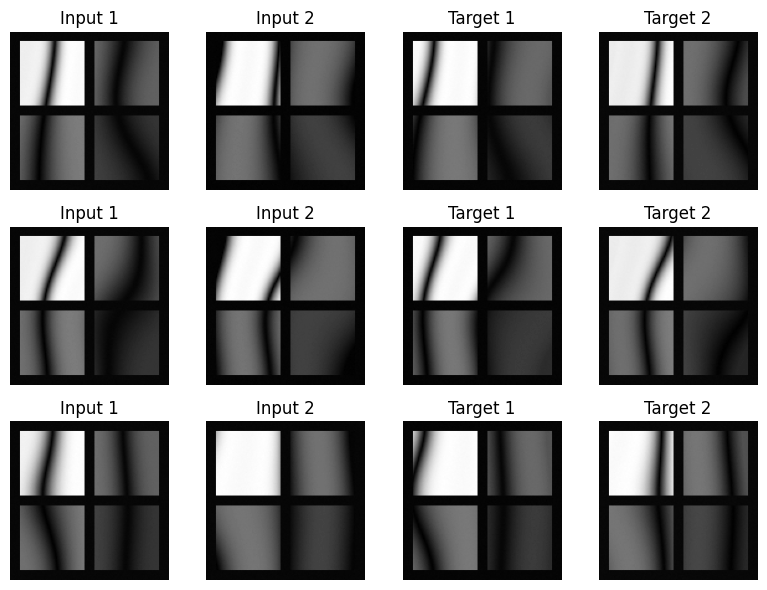

In [3]:
if(os.path.isfile(ds_path)):
    print(f'Saved dataset found. Loading from file: {ds_path}')
    dataset = np.load(ds_path, allow_pickle=True)[0]
else:
    slices = 200
    dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1, 2, 3, 4],
                                          npcs=4, f=500, alpha=np.deg2rad(60), sigma=0.001, data_indices=[(0, 2), (120,180)], 
                                          useRotate=True, useDeform=True)
    np.save(ds_path, [dataset])

data = dataset['M']
data.shape
mssfp.plot_dataset(data, slice=0)
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    num_samples=3
)

In [4]:
# Basic training
model, history, ds, predictions = deepssfp.train(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir,
    custom_dataset=ds,
    epochs=400,
    use_early_stopping=False,
    patience=200,
    continue_training=True
)

2025-03-20 23:41:31,323 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block_phantom_syntheticbanding
2025-03-20 23:41:31,324 - DeepSSFP - INFO - Training DataSet: (160, 128, 128, 4) | (160, 128, 128, 4)
2025-03-20 23:41:31,325 - DeepSSFP - INFO - Test DataSet: (40, 128, 128, 4) | (40, 128, 128, 4)
2025-03-20 23:41:31,888 - DeepSSFP - INFO - Loading existing model from D:/DeepSSFP/block_phantom_syntheticbanding.keras
2025-03-20 23:41:33,117 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_syntheticbanding_history.npz
2025-03-20 23:41:33,121 - DeepSSFP - INFO - Continuing training from epoch 400


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 4) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
______________________________________________________________________________________________

2025-03-20 23:41:33,477 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block_phantom_syntheticbanding.keras


2/2 [==============================] - 3s 368ms/step - loss: 1.9036e-04 - mean_absolute_error: 0.0105


2025-03-20 23:41:37,126 - DeepSSFP - INFO - Training Complete. Loss: 0.0002, MAE: 0.0105
2025-03-20 23:41:37,126 - DeepSSFP - INFO - Time Elapsed: 4.00 seconds


2025-03-20 23:41:37,146 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/block_phantom_syntheticbanding
2025-03-20 23:41:37,646 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/block_phantom_syntheticbanding.keras
2025-03-20 23:41:37,646 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_syntheticbanding_history.npz
2025-03-20 23:41:38,544 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block_phantom_syntheticbanding_training_history.png


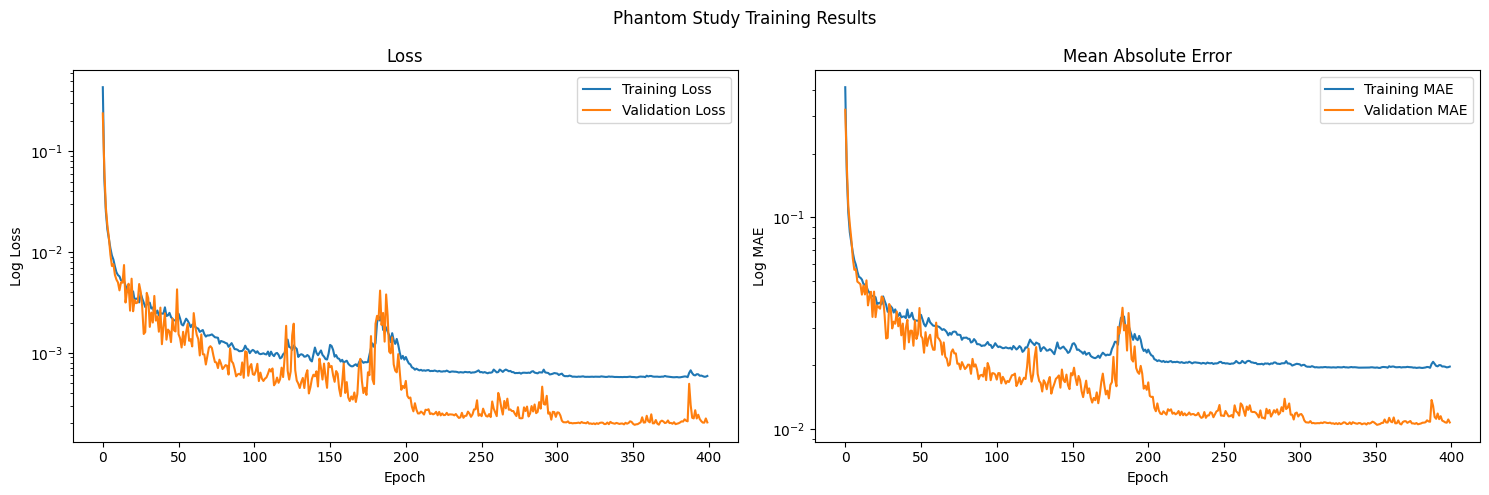

In [5]:
model, history_dict = deepssfp.load_model(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir
)

deepssfp.plot_training_history(
    history_dict,
    title="Phantom Study Training Results",
    save_path=f"{path}_training_history.png"
)

In [6]:
ds = deepssfp.Dataset(mode, input_data=data)
predictions = deepssfp.predict(model, ds.x_test)

2025-03-20 23:41:39,375 - DeepSSFP - INFO - Making predictions on data with shape (40, 128, 128, 4)
2025-03-20 23:41:40,336 - DeepSSFP - INFO - Predictions complete. Output shape: (40, 128, 128, 4)


(40, 128, 128, 4) float32
(40, 128, 128, 4) (40, 128, 128, 4) float64 float64
Figure size: (16, 2)
Image visualization saved to D:/DeepSSFP/block_phantom_syntheticbanding_prediction_results.png


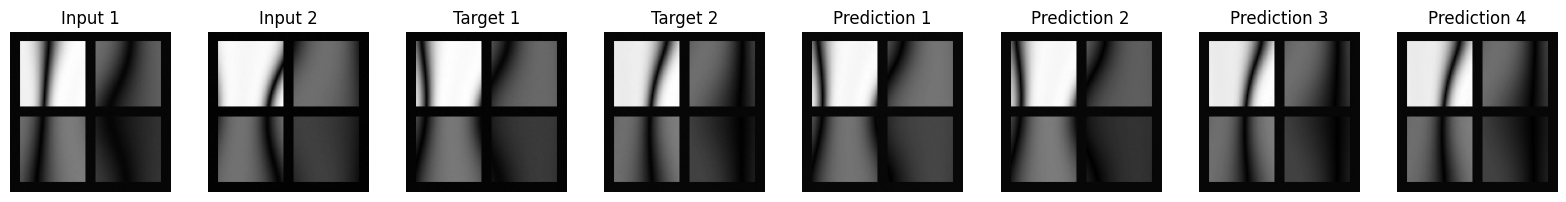

In [7]:
print(predictions.shape, predictions.dtype)
print(ds.x_test.shape, ds.y_test.shape, ds.x_test.dtype, ds.y_test.dtype)
deepssfp.visualize_images([0], ds.x_test, ds.y_test, predictions, save_path=f"{path}_prediction_results.png")

(40, 128, 128, 8) (40, 128, 128) (40, 128, 128)
Selected indices: [14]
Figure size: (12, 2)


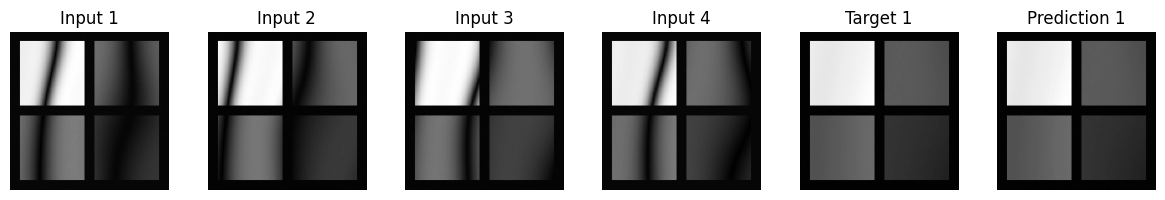

In [8]:
import deepssfp.recon
target = deepssfp.combine_synthetic_banding_datasets(ds.x_test, ds.y_test)
target = deepssfp.recon.gs_recon_3d(target)

combine = deepssfp.combine_synthetic_banding_datasets(ds.x_test, predictions)
pred = deepssfp.recon.gs_recon_3d(combine)
print(combine.shape, target.shape, pred.shape)

deepssfp.visualize_images(
    input_images=combine,
    target_images=target,
    predicted_images=pred
)

Target shape: (40, 128, 128)
Prediction shape: (40, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4.]
IDs to plot: [1. 2. 3. 4.]
Training history plot saved to D:/DeepSSFP/block_phantom_syntheticbanding_metrics2_scatter


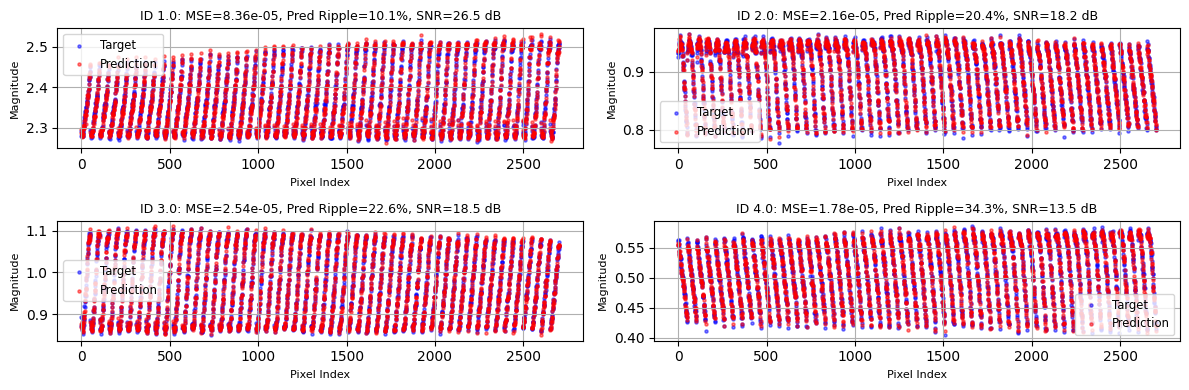

Training history plot saved to D:/DeepSSFP/block_phantom_syntheticbanding_metrics2


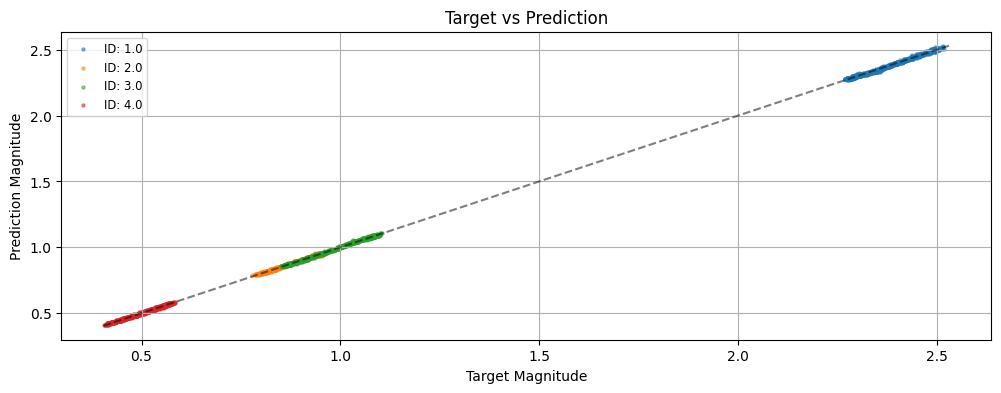


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=8.36e-05, MAE=6.39e-03, Pred Min=2.2658, Pred Max=2.5051, Pred Ripple=10.15%, Pred SNR=26.5 dB, Target Min=2.2663, Target Max=2.4917, Target Ripple=9.57%, Target SNR=26.5 dB, Samples=40, Pixels=2704
ID 2.0: MSE=2.16e-05, MAE=3.61e-03, Pred Min=0.7818, Pred Max=0.9654, Pred Ripple=20.43%, Pred SNR=18.2 dB, Target Min=0.7810, Target Max=0.9673, Target Ripple=20.74%, Target SNR=18.2 dB, Samples=40, Pixels=2704
ID 3.0: MSE=2.54e-05, MAE=3.92e-03, Pred Min=0.8514, Pred Max=1.0634, Pred Ripple=22.62%, Pred SNR=18.5 dB, Target Min=0.8494, Target Max=1.0588, Target Ripple=22.35%, Target SNR=18.5 dB, Samples=40, Pixels=2704
ID 4.0: MSE=1.78e-05, MAE=3.33e-03, Pred Min=0.4066, Pred Max=0.5848, Pred Ripple=34.28%, Pred SNR=13.5 dB, Target Min=0.4049, Target Max=0.5875, Target Ripple=35.14%, Target SNR=13.4 dB, Samples=40, Pixels=2704
{1.0: {'mse': 8.36454710880265e-05, 'mae': 0.00638775212798276, 'pred_min': 2.2658399920134014, 'pr

In [9]:
metrics = deepssfp.evaluate_band_reduction(target, pred, dataset['seg'], sort_values=False, fig_size=(6, 2), save_path=f"{path}_metrics2")
print(metrics)